# Bug Title Optimizer — tianocore/edk2

Fetches open [`type:bug`](https://github.com/tianocore/edk2/issues?q=is%3Aissue+state%3Aopen+label%3Atype%3Abug) issues (title + full body), sends each to **Claude** with a detailed edk2 optimization rubric, and returns an optimized title with a confidence score.

**Pipeline:** Fetch issues (title + body) → LLM optimization → Confidence-scored results → JSON + CSV export


In [53]:
# Cell 1: Install dependencies
!pip install anthropic requests --quiet
print("Dependencies installed")


Dependencies installed


## Step 1 — API Keys

Keys are loaded from **Colab Secrets** (the key icon in the left sidebar).
Add your secrets there with the toggle enabled for this notebook:

| Secret name | What it is |
|---|---|
| `ANTHROPIC_API_KEY` | Your Anthropic key — https://console.anthropic.com |
| `GITHUB_TOKEN` | GitHub personal access token (optional, but raises rate limit from 60 to 5,000 req/hr) — https://github.com/settings/tokens |

> **How to add a secret:** Click the key icon in the left sidebar → *Add new secret* → paste the value → toggle *Notebook access* ON.


In [54]:
# Cell 2: Load API keys from Colab Secrets
import os
from google.colab import userdata

def get_secret(name):
    """Read from Colab Secrets first, fall back to os.environ."""
    try:
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    return os.environ.get(name, "")

ANTHROPIC_KEY = get_secret("ANTHROPIC_API_KEY")
GITHUB_TOKEN  = get_secret("GITHUB_TOKEN")

print("ANTHROPIC_API_KEY:", "OK (set)" if ANTHROPIC_KEY else "MISSING — add it in Colab Secrets (key icon in sidebar)")
print("GITHUB_TOKEN     :", "OK (set)" if GITHUB_TOKEN  else "not set — unauthenticated (60 req/hr limit)")

if not ANTHROPIC_KEY:
    raise EnvironmentError(
        "ANTHROPIC_API_KEY not found.\n"
        "Go to the key icon in the left sidebar → Add new secret:\n"
        "  Name: ANTHROPIC_API_KEY   Value: sk-ant-...\n"
        "Then toggle 'Notebook access' ON and re-run this cell."
    )


ANTHROPIC_API_KEY: OK (set)
GITHUB_TOKEN     : OK (set)


## Step 2 — Configuration

In [55]:
# Cell 3: Configuration
# @title Configuration { run: "auto" }
GITHUB_REPO   = 'tianocore/edk2'
ISSUE_LABEL   = 'type:bug'
ISSUE_STATE   = 'open'
GITHUB_API    = 'https://api.github.com'

MAX_ISSUES   = 20    # @param {type:"slider", min:5, max:100, step:5}
AI_DELAY_SEC = 0.5   # @param {type:"number"}
RUN_AI       = True  # @param {type:"boolean"}

IDEAL_MIN_LEN = 50
IDEAL_MAX_LEN = 100

print(f'Config: {MAX_ISSUES} issues, AI={"on" if RUN_AI else "off"}')


Config: 20 issues, AI=on


## Step 3 — Data model

In [56]:
# Cell 4: Data model
import re, json, time
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class IssueAnalysis:
    number:                        int
    url:                           str
    original_title:                str
    body:                          str
    labels:                        list

    # LLM results
    optimized_title:               str  = ''
    title_quality_score:           int  = 0
    title_quality_reason:          str  = ''
    description_confidence:        int  = 0
    description_confidence_reason: str  = ''
    reflective_confidence:        int = 0
    reflective_confidence_reason: str = ''
    original_issues:               list = field(default_factory=list)
    context_used:                  list = field(default_factory=list)
    ai_error:                      Optional[str] = None

def prepare_issue(issue):
    return IssueAnalysis(
        number = issue['number'],
        url    = issue['html_url'],
        original_title = issue['title'].strip(),
        body   = (issue.get('body') or '').strip(),
        labels = [l['name'] for l in issue.get('labels', [])],
    )

print('Data model defined')


Data model defined


## Step 4 — Fetch issues from GitHub (title + full body)

In [57]:
# Cell 5: Fetch issues
import requests

def validate_github_token(token):
    """Quick check: verify token works before using it. Returns (valid, message)."""
    if not token:
        return False, "no token provided"
    resp = requests.get(
        f"{GITHUB_API}/user",
        headers={"Accept": "application/vnd.github+json", "Authorization": f"Bearer {token}"},
        timeout=10,
    )
    if resp.status_code == 200:
        return True, resp.json().get("login", "unknown")
    elif resp.status_code == 401:
        return False, "token is invalid or expired (401)"
    else:
        return False, f"unexpected status {resp.status_code}"

def fetch_issues(token, max_issues):
    headers = {"Accept": "application/vnd.github+json"}
    if token:
        headers["Authorization"] = f"Bearer {token}"
    issues, page = [], 1
    per_page = min(100, max_issues)
    while len(issues) < max_issues:
        url = (f"{GITHUB_API}/repos/{GITHUB_REPO}/issues"
               f"?state={ISSUE_STATE}&labels={ISSUE_LABEL}"
               f"&per_page={per_page}&page={page}")
        resp = requests.get(url, headers=headers, timeout=30)
        if resp.status_code == 401:
            raise RuntimeError(
                "GitHub 401 Unauthorized.\n"
                "Your GITHUB_TOKEN is invalid or expired. Fix options:\n"
                "  1. Generate a new token at https://github.com/settings/tokens\n"
                "     (classic token, no scopes needed for public repos)\n"
                "  2. Update the value in Colab Secrets (key icon in sidebar)\n"
                "  3. Or set GITHUB_TOKEN = '' below to fetch without auth (60 req/hr limit)"
            )
        if resp.status_code == 403:
            raise RuntimeError("GitHub 403: rate limit hit. Add or refresh your GITHUB_TOKEN.")
        resp.raise_for_status()
        batch = resp.json()
        if not batch: break
        issues.extend(i for i in batch if "pull_request" not in i)
        page += 1
        if len(batch) < per_page: break
    return issues[:max_issues]

# Validate token before fetching
token_valid, token_info = validate_github_token(GITHUB_TOKEN)
if GITHUB_TOKEN:
    if token_valid:
        print(f"GitHub token OK — authenticated as: {token_info}")
    else:
        print(f"WARNING: GitHub token check failed — {token_info}")
        print("Tip: go to https://github.com/settings/tokens and generate a new classic token,")
        print("     then update it in Colab Secrets (key icon in sidebar).")
        print("Continuing without auth (60 req/hr limit)...")
        GITHUB_TOKEN = ""  # fall back to unauthenticated
else:
    print("No GitHub token — fetching unauthenticated (60 req/hr limit)")

print(f"Fetching up to {MAX_ISSUES} open {ISSUE_LABEL!r} issues from {GITHUB_REPO}...")
raw_issues = fetch_issues(GITHUB_TOKEN, MAX_ISSUES)
print(f"Fetched {len(raw_issues)} issues")


GitHub token OK — authenticated as: nazaninsiavash
Fetching up to 20 open 'type:bug' issues from tianocore/edk2...
Fetched 20 issues


## Step 5 — Prepare issues

In [58]:
# Cell 6: Prepare issues
results = [prepare_issue(issue) for issue in raw_issues]
print(f'Prepared {len(results)} issues for LLM optimization')
print(f'Issues with non-empty body: {sum(1 for r in results if r.body)}')


Prepared 20 issues for LLM optimization
Issues with non-empty body: 20


## Step 6 — LLM optimization

Every issue (title + full body up to 1,500 chars) is sent to Claude with a rubric covering:
- Package/module naming
- Concrete symptom (not vague)
- Trigger/condition
- edk2 title convention (`Package: symptom condition`)
- Length 50–100 chars


In [59]:
# Cell 7: LLM optimization
import anthropic

AI_SYSTEM = """You are an expert edk2/UEFI firmware engineer who reviews and improves GitHub issue titles.
You have deep knowledge of the tianocore/edk2 codebase, its packages, modules, and conventions.
Respond ONLY with valid JSON — no markdown, no preamble, no explanation."""

AI_PROMPT = """Review this edk2 GitHub bug report and produce an optimized title.

ORIGINAL TITLE: "{title}"
DESCRIPTION:
{body}
LABELS: {labels}

A well-optimized edk2 bug title must satisfy ALL of these conditions:
1. NAME the package or module (e.g. MdeModulePkg, NetworkPkg, OvmfPkg, DxeCore, BaseTools)
2. STATE the concrete symptom (ASSERT fail, NULL pointer dereference, build error, hang,
   incorrect output, memory corruption, boot failure, wrong return value)
3. INCLUDE the trigger or condition when known (on GCC5, during S3 resume, when secure boot enabled,
   with >4GB RAM, on QEMU, when capsule update runs)
4. LENGTH: 50-100 characters
5. FOLLOW the format 'Package/Module: symptom condition'
   where Package is the edk2 package and Module is the specific driver/library/tool.
   If only the package is known, use 'Package: symptom condition'.
   Examples:
   'MdeModulePkg/NvmeDxe: Memory leak on PciIo->Attributes failure'  <- package/module
   'BaseTools/VfrCompile: build fails with parallel make race'        <- package/module
   'SecurityPkg/Tcg2: LAML/LASL offsets wrong in TPM2 ACPI table'    <- package/module
   'BaseTools: No error when UEFI_DRIVER has invalid [Depex] section' <- package only
6. AVOID vague words: issue, problem, broken, wrong, not working, something wrong, bad

Title quality score (0-100) — how well the GENERATED title satisfies the 6 criteria above:
- 90-100: satisfies all 6 criteria perfectly
- 70-89:  satisfies most criteria, minor gap (e.g. condition missing but not available)
- 50-69:  satisfies some criteria but missing key elements like module name or concrete symptom
- 20-49:  only partially improved, still vague or too generic
- 0-19:   could not meaningfully improve the title

Description confidence score (0-100) — how much the DESCRIPTION helped generate the title:
- 90-100: description had stack trace, exact error code, module name, and repro steps
- 70-89:  description had module name and symptom but missing repro or exact error
- 50-69:  description had some useful hints but key details were vague or missing
- 20-49:  description was sparse; title largely inferred from original title alone
- 0-19:   description was empty or useless; title is a best guess with high uncertainty

Reflective confidence score (0-100) — step back and honestly assess: is the optimized title genuinely better than the original?
- 90-100: clearly better — more specific, actionable, and easier to triage than the original
- 70-89:  mostly better — improves key weaknesses but may lose some nuance from the original
- 50-69:  marginally better — minor improvements, original was already reasonable
- 20-49:  uncertain — the optimized title may not be better, just different
- 0-19:   original may actually be better — optimization changed meaning or made it worse

Respond ONLY with this JSON:
{{
  "optimized_title": "<the single best title, 50-100 chars>",
  "title_quality_score": <0-100>,
  "title_quality_reason": "<one sentence: how well the generated title meets the 6 criteria>",
  "description_confidence": <0-100>,
  "description_confidence_reason": "<one sentence: how much the description helped>",
  "reflective_confidence": <0-100>,
  "reflective_confidence_reason": "<one sentence: is this title genuinely better than the original, and why>",
  "original_issues": ["<what was wrong with the original title>"],
  "context_used": ["<what info from the description was used to improve the title>"]
}}"""

def run_ai_optimization(analysis, client):
    body_text = analysis.body[:1500] if analysis.body else '(no description provided)'
    prompt = AI_PROMPT.format(
        title  = analysis.original_title,
        body   = body_text,
        labels = ', '.join(analysis.labels) if analysis.labels else 'none',
    )
    try:
        msg = client.messages.create(
            model       = 'claude-sonnet-4-6',
            max_tokens  = 1200,
            temperature = 0,
            system      = AI_SYSTEM,
            messages    = [{'role': 'user', 'content': prompt}],
        )
        raw    = msg.content[0].text.strip()
        print(f"RAW RESPONSE: {raw[:500]}")
        raw    = re.sub(r'^```(?:json)?|```$', '', raw, flags=re.MULTILINE).strip()
        parsed = json.loads(raw)
        analysis.optimized_title               = parsed.get('optimized_title', '')
        analysis.title_quality_score           = int(parsed.get('title_quality_score', 0))
        analysis.title_quality_reason          = parsed.get('title_quality_reason', '')
        analysis.description_confidence        = int(parsed.get('description_confidence', 0))
        analysis.description_confidence_reason = parsed.get('description_confidence_reason', '')
        analysis.reflective_confidence         = int(parsed.get('reflective_confidence', 0))
        analysis.reflective_confidence_reason  = parsed.get('reflective_confidence_reason', '')
        analysis.original_issues               = parsed.get('original_issues', [])
        analysis.context_used                  = parsed.get('context_used', [])
    except Exception as exc:
        analysis.ai_error = str(exc)

if not RUN_AI:
    print('AI skipped (RUN_AI=False)')
elif not ANTHROPIC_KEY:
    print('No Anthropic key - skipping AI')
else:
    client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    print(f'Running LLM optimization on {len(results)} issues...')
    for idx, analysis in enumerate(results, 1):
        print(f'  [{idx:>3}/{len(results)}] #{analysis.number}: {analysis.original_title[:60]}...')
        run_ai_optimization(analysis, client)
        if idx < len(results):
            time.sleep(AI_DELAY_SEC)
    ai_ok  = sum(1 for r in results if r.optimized_title)
    ai_err = sum(1 for r in results if r.ai_error)
    avg_tq = sum(r.title_quality_score    for r in results if r.optimized_title) / ai_ok if ai_ok else 0
    avg_dc = sum(r.description_confidence for r in results if r.optimized_title) / ai_ok if ai_ok else 0
    avg_rc = sum(r.reflective_confidence  for r in results if r.optimized_title) / ai_ok if ai_ok else 0
    print(f'Done: {ai_ok} optimized, {ai_err} errors')
    print(f'Avg title quality score    : {avg_tq:.0f}/100')
    print(f'Avg description confidence : {avg_dc:.0f}/100')
    print(f'Avg reflective confidence  : {avg_rc:.0f}/100')

Running LLM optimization on 20 issues...
  [  1/20] #12651: [Bug]: Booting netboot.xyz over HTTPS fails with "EE certifi...
RAW RESPONSE: {
  "optimized_title": "CryptoPkg/TlsLib: HTTPS boot fails due to \"EE certificate key too weak\"",
  "title_quality_score": 85,
  "title_quality_reason": "Names the package and module, states the concrete symptom (HTTPS boot failure) with the exact error string, and follows the required format; condition (HTTPS boot) is included but target environment detail is implicit.",
  "description_confidence": 88,
  "description_confidence_reason": "Description provided the exact TLS error message, the s
  [  2/20] #12646: [Bug]: ArmStandaloneMmCoreEntryPoint DelegatedEventLoop infi...
RAW RESPONSE: {
  "optimized_title": "ArmPkg/StandaloneMmCoreEntryPoint: System hang in DelegatedEventLoop on invalid FF-A response",
  "title_quality_score": 82,
  "title_quality_reason": "Names the package and module, states the concrete symptom (system hang), and includes th

## Step 7 — Per-issue results

In [60]:
# Cell 8: Render per-issue results
from IPython.display import display, HTML

def quality_badge(score):
    if score >= 75:   color = '#2d9e6b'
    elif score >= 50: color = '#d4860a'
    else:             color = '#c0392b'
    return f"<span style='background:{color};color:#fff;padding:2px 8px;border-radius:4px;font-size:12px;font-weight:600'>Title quality {score}/100</span>"

def confidence_badge(score):
    if score >= 75:   color = '#185fa5'
    elif score >= 50: color = '#8e44ad'
    else:             color = '#555'
    return f"<span style='background:{color};color:#fff;padding:2px 8px;border-radius:4px;font-size:12px;font-weight:600'>Description confidence {score}/100</span>"

def render_issue(a, idx, total):
    if a.ai_error:
        ai_block = f"<div style='color:#c0392b;font-size:13px;margin-top:8px'>AI error: {a.ai_error}</div>"
    elif a.optimized_title:
        issues_li  = ''.join(f'<li>{i}</li>' for i in a.original_issues)
        context_li = ''.join(f'<li>{c}</li>' for c in a.context_used) or '<li>None — description was empty</li>'
        ai_block = f"""
        <div style='margin-top:10px;padding:10px 14px;background:#f8f9ff;border-left:3px solid #4a6cf7;border-radius:0 6px 6px 0'>
          <div style='display:flex;align-items:center;gap:8px;margin-bottom:8px;flex-wrap:wrap'>
            <span style='font-size:13px;font-weight:600'>Optimized title</span>
            {quality_badge(a.title_quality_score)}
            {confidence_badge(a.description_confidence)}
          </div>
          <code style='background:#1a1a2e;color:#7eb8f7;padding:6px 12px;border-radius:4px;font-size:13px;display:block;margin-bottom:6px'>{a.optimized_title}</code>
          <div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-bottom:8px'>
            <p style='font-size:12px;color:#444;margin:0'><b>Title quality:</b> {a.title_quality_reason}</p>
            <p style='font-size:12px;color:#444;margin:0'><b>Description confidence:</b> {a.description_confidence_reason}</p>
          </div>
          <div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-top:8px'>
            <div><p style='font-size:12px;font-weight:600;margin:0 0 3px'>What was wrong</p><ul style='font-size:12px;color:#555;margin:0;padding-left:16px'>{issues_li}</ul></div>
            <div><p style='font-size:12px;font-weight:600;margin:0 0 3px'>Context used from description</p><ul style='font-size:12px;color:#555;margin:0;padding-left:16px'>{context_li}</ul></div>
          </div>
        </div>"""
    else:
        ai_block = "<div style='color:#888;font-size:13px;margin-top:8px'>AI not run</div>"

    labels_html = ' '.join(
        f"<span style='background:#eef;color:#44a;font-size:11px;padding:1px 6px;border-radius:3px'>{l}</span>"
        for l in a.labels
    )

    return f"""<div style='border:1px solid #e0e0e0;border-radius:8px;padding:14px 18px;margin-bottom:12px;background:#fff'>
  <div style='display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:6px'>
    <span style='font-size:12px;color:#888'>#{a.number} &nbsp; {idx}/{total}</span>
    <div style='display:flex;flex-wrap:wrap;gap:4px'>{labels_html}</div>
  </div>
  <p style='margin:0 0 2px;font-size:14px;font-weight:600;color:#333'>Original: {a.original_title}</p>
  <a href='{a.url}' target='_blank' style='font-size:12px;color:#4a6cf7'>{a.url}</a>
  {ai_block}
</div>"""

# Display each issue separately to avoid Colab output truncation
for i, a in enumerate(results):
    display(HTML(render_issue(a, i+1, len(results))))


## Step 8 — Summary dashboard

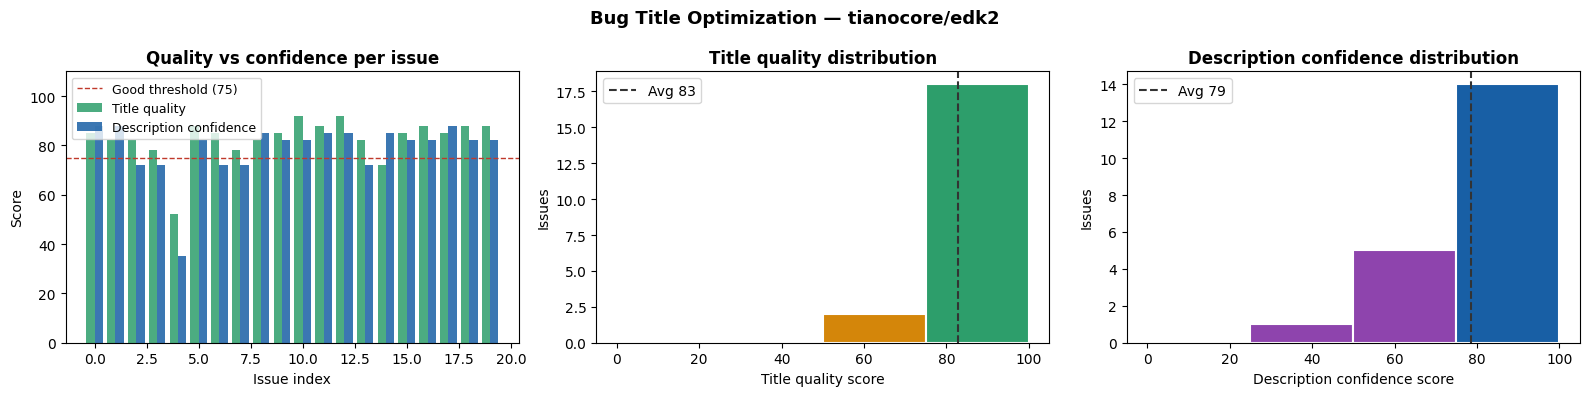

Issues processed              : 20
Successfully optimized        : 20
Avg title quality score       : 83/100
Avg description confidence    : 79/100
Title quality   >= 75 (good)  : 18
Description conf >= 75 (high) : 14


In [61]:
# Cell 9: Summary dashboard
import matplotlib.pyplot as plt
import numpy as np

optimized = [r for r in results if r.optimized_title]
tq_scores = [r.title_quality_score    for r in optimized]
dc_scores = [r.description_confidence for r in optimized]
total     = len(results)
avg_tq    = sum(tq_scores) / len(tq_scores) if tq_scores else 0
avg_dc    = sum(dc_scores) / len(dc_scores) if dc_scores else 0

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Bug Title Optimization — tianocore/edk2', fontsize=13, fontweight='bold')

# Grouped bar: title quality vs description confidence per issue
x = np.arange(len(optimized))
w = 0.4
axes[0].bar(x - w/2, tq_scores, w, label='Title quality',          color='#2d9e6b', alpha=0.85)
axes[0].bar(x + w/2, dc_scores, w, label='Description confidence', color='#185fa5', alpha=0.85)
axes[0].axhline(75, color='#c0392b', linestyle='--', linewidth=1, label='Good threshold (75)')
axes[0].set_title('Quality vs confidence per issue', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Issue index')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 110)

# Histogram: title quality score distribution
n, edges, patches = axes[1].hist(tq_scores, bins=[0,25,50,75,100], edgecolor='white', linewidth=1.5)
for patch, color in zip(patches, ['#c0392b','#e67e22','#d4860a','#2d9e6b']):
    patch.set_facecolor(color)
axes[1].axvline(avg_tq, color='#333', linestyle='--', linewidth=1.5, label=f'Avg {avg_tq:.0f}')
axes[1].set_xlabel('Title quality score')
axes[1].set_ylabel('Issues')
axes[1].set_title('Title quality distribution', fontweight='bold')
axes[1].legend(fontsize=10)

# Histogram: description confidence distribution
n, edges, patches = axes[2].hist(dc_scores, bins=[0,25,50,75,100], edgecolor='white', linewidth=1.5)
for patch, color in zip(patches, ['#555','#8e44ad','#8e44ad','#185fa5']):
    patch.set_facecolor(color)
axes[2].axvline(avg_dc, color='#333', linestyle='--', linewidth=1.5, label=f'Avg {avg_dc:.0f}')
axes[2].set_xlabel('Description confidence score')
axes[2].set_ylabel('Issues')
axes[2].set_title('Description confidence distribution', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('bug_title_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Issues processed              : {total}')
print(f'Successfully optimized        : {len(optimized)}')
print(f'Avg title quality score       : {avg_tq:.0f}/100')
print(f'Avg description confidence    : {avg_dc:.0f}/100')
print(f'Title quality   >= 75 (good)  : {sum(1 for s in tq_scores if s >= 75)}')
print(f'Description conf >= 75 (high) : {sum(1 for s in dc_scores if s >= 75)}')


## Step 9 — Export JSON + CSV

In [62]:
# Cell 10: Export JSON + CSV and download
import json, csv
from google.colab import files

# ── JSON ──────────────────────────────────────────────────────────────────
report = [{
    'number':                        a.number,
    'url':                           a.url,
    'labels':                        a.labels,
    'original_title':                a.original_title,
    'optimized_title':               a.optimized_title,
    'title_quality_score':           a.title_quality_score,
    'title_quality_reason':          a.title_quality_reason,
    'description_confidence':        a.description_confidence,
    'description_confidence_reason': a.description_confidence_reason,
    'reflective_confidence':        a.reflective_confidence,
'reflective_confidence_reason': a.reflective_confidence_reason,
    'original_issues':               a.original_issues,
    'context_used':                  a.context_used,
    'ai_error':                      a.ai_error,
} for a in results]

with open('bug_title_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print('Saved: bug_title_report.json')

# ── CSV ───────────────────────────────────────────────────────────────────
CSV_FIELDS = [
    'number', 'url', 'labels',
    'original_title', 'optimized_title',
    'title_quality_score', 'title_quality_reason',
    'description_confidence', 'description_confidence_reason',
    'reflective_confidence','reflective_confidence_reason',
    'original_issues', 'context_used',
    'ai_error',
]

with open('bug_title_report.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
    writer.writeheader()
    for a in results:
        writer.writerow({
            'number':                        a.number,
            'url':                           a.url,
            'labels':                        ' | '.join(a.labels),
            'original_title':                a.original_title,
            'optimized_title':               a.optimized_title,
            'title_quality_score':           a.title_quality_score,
            'title_quality_reason':          a.title_quality_reason,
            'description_confidence':        a.description_confidence,
            'description_confidence_reason': a.description_confidence_reason,
            'reflective_confidence':         a.reflective_confidence,
            'reflective_confidence_reason':  a.reflective_confidence_reason,
            'original_issues':               ' | '.join(a.original_issues),
            'context_used':                  ' | '.join(a.context_used),
            'ai_error':                      a.ai_error or '',
        })
print('Saved: bug_title_report.csv')

# ── Download all ──────────────────────────────────────────────────────────
files.download('bug_title_report.json')
files.download('bug_title_report.csv')
files.download('bug_title_quality.png')
print('Downloads triggered')


Saved: bug_title_report.json
Saved: bug_title_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered


In [63]:
# Cell 11: Filter high-quality optimizations (reflective >= 80 and title quality >= 80)
high_quality = [r for r in results if r.reflective_confidence >= 80 and r.title_quality_score >= 80]

print(f"Issues with reflective confidence >= 80 AND title quality score >= 80: {len(high_quality)} / {len(results)}")
print()

for r in high_quality:
    print(f"#{r.number}")
    print(f"  Original  : {r.original_title}")
    print(f"  Optimized : {r.optimized_title}")
    print(f"  Title quality     : {r.title_quality_score}/100 — {r.title_quality_reason}")
    print(f"  Reflective conf   : {r.reflective_confidence}/100 — {r.reflective_confidence_reason}")
    print()

Issues with reflective confidence >= 80 AND title quality score >= 80: 13 / 20

#12651
  Original  : [Bug]: Booting netboot.xyz over HTTPS fails with "EE certificate key too weak"
  Optimized : CryptoPkg/TlsLib: HTTPS boot fails due to "EE certificate key too weak"
  Title quality     : 85/100 — Names the package and module, states the concrete symptom (HTTPS boot failure) with the exact error string, and follows the required format; condition (HTTPS boot) is included but target environment detail is implicit.
  Reflective conf   : 82/100 — The optimized title is more specific by naming CryptoPkg/TlsLib and preserving the exact error string, making it easier to triage than the original which lacked package/module identification.

#12587
  Original  : [Bug]: TPM table offset to LAML and LASL are incorrect
  Optimized : SecurityPkg/Tcg2Acpi: LAML/LASL offsets incorrect in TPM2 ACPI table
  Title quality     : 88/100 — Names the package and module, states the concrete symptom (incorrect o